In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8')


## Load Online Payments Dataset

In [3]:
DATA_PATH = Path('../data/raw/online_payments.csv')

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 1. Transaction Analysis

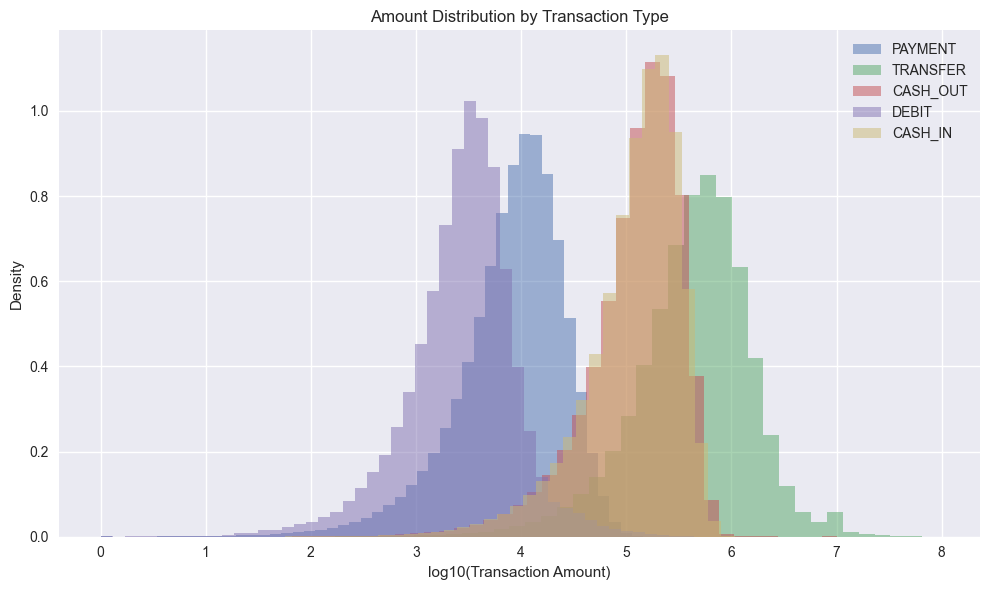

In [4]:
plt.figure(figsize=(10,6))

for t in df['type'].unique():
    subset = df[df['type'] == t]
    plt.hist(np.log10(subset['amount'].clip(lower=1)), 
             bins=50, alpha=0.5, label=t, density=True)

plt.xlabel("log10(Transaction Amount)")
plt.ylabel("Density")
plt.title("Amount Distribution by Transaction Type")
plt.legend()
plt.tight_layout()
plt.show()


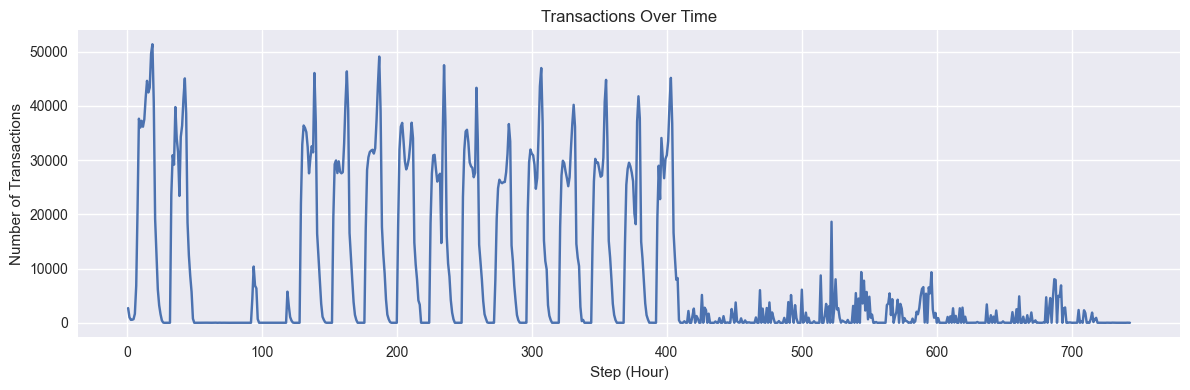

Total duration: 742 hours


In [5]:
# Transactions per hour (step represents hour)
tx_per_step = df.groupby('step').size()

plt.figure(figsize=(12,4))
plt.plot(tx_per_step)
plt.xlabel("Step (Hour)")
plt.ylabel("Number of Transactions")
plt.title("Transactions Over Time")
plt.tight_layout()
plt.show()

print(f"Total duration: {df['step'].max() - df['step'].min()} hours")


Sender activity statistics:
count    6.353307e+06
mean     1.001466e+00
std      3.832002e-02
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.000000e+00
dtype: float64


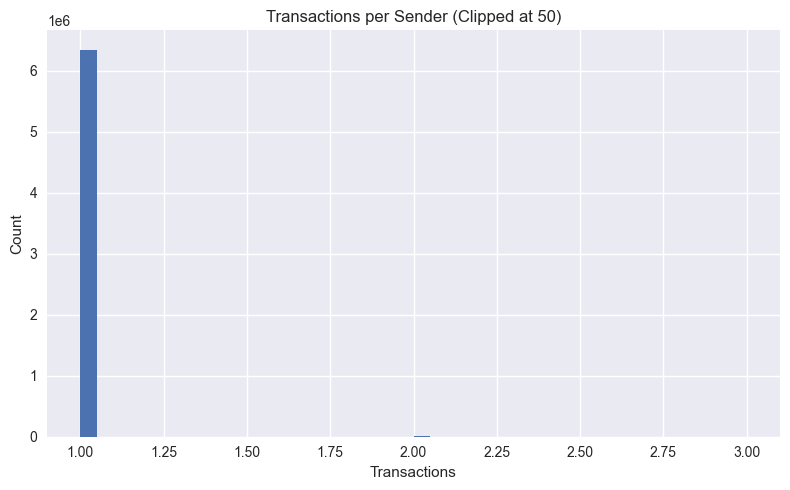

In [6]:
tx_per_sender = df.groupby('nameOrig').size()
tx_per_receiver = df.groupby('nameDest').size()

print("Sender activity statistics:")
print(tx_per_sender.describe())

plt.figure(figsize=(8,5))
plt.hist(tx_per_sender.clip(upper=50), bins=40)
plt.title("Transactions per Sender (Clipped at 50)")
plt.xlabel("Transactions")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 2. Fraud Patterns

In [7]:
fraud_by_type = df.groupby('type')['isFraud'].agg(['sum','count'])
fraud_by_type['fraud_rate_%'] = fraud_by_type['sum'] / fraud_by_type['count'] * 100

fraud_by_type.sort_values('fraud_rate_%', ascending=False)


,sum,count,fraud_rate_%
type,,,
TRANSFER,4097,532909,0.768799
CASH_OUT,4116,2237500,0.183955
CASH_IN,0,1399284,0.000000
DEBIT,0,41432,0.000000
PAYMENT,0,2151495,0.000000


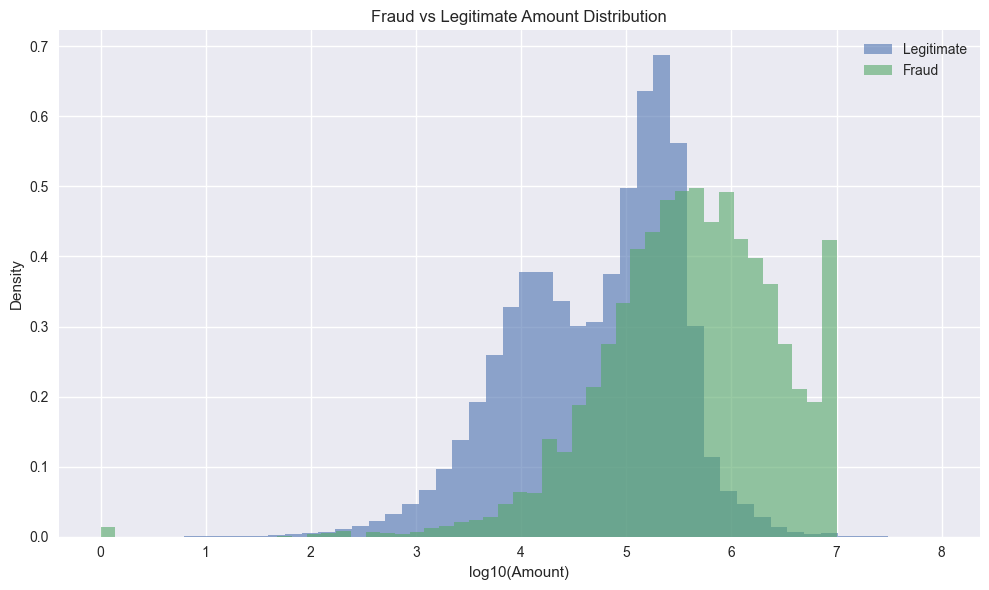

Fraud Amount Stats:
count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64


In [8]:
fraud_df = df[df['isFraud'] == 1]
legit_df = df[df['isFraud'] == 0]

plt.figure(figsize=(10,6))
plt.hist(np.log10(legit_df['amount'].clip(lower=1)), bins=50, alpha=0.6, label='Legitimate', density=True)
plt.hist(np.log10(fraud_df['amount'].clip(lower=1)), bins=50, alpha=0.6, label='Fraud', density=True)
plt.legend()
plt.xlabel("log10(Amount)")
plt.ylabel("Density")
plt.title("Fraud vs Legitimate Amount Distribution")
plt.tight_layout()
plt.show()

print("Fraud Amount Stats:")
print(fraud_df['amount'].describe())


In [9]:
tp = ((df['isFlaggedFraud'] == 1) & (df['isFraud'] == 1)).sum()
fp = ((df['isFlaggedFraud'] == 1) & (df['isFraud'] == 0)).sum()
fn = ((df['isFlaggedFraud'] == 0) & (df['isFraud'] == 1)).sum()

print("Rule-based System Performance")
print(f"True Positives: {tp}")
print(f"False Positives: {fp}")
print(f"Missed Fraud (FN): {fn}")

if tp + fn > 0:
    print(f"Recall: {tp/(tp+fn):.4f}")


Rule-based System Performance
True Positives: 16
False Positives: 0
Missed Fraud (FN): 8197
Recall: 0.0019


## 3. Account Network Analysis

In [10]:
top_senders = tx_per_sender.sort_values(ascending=False).head(10)
top_receivers = tx_per_receiver.sort_values(ascending=False).head(10)

print("Top 10 Senders:")
print(top_senders)

print("\nTop 10 Receivers:")
print(top_receivers)


Top 10 Senders:
nameOrig
C1832548028    3
C1530544995    3
C1065307291    3
C1902386530    3
C1784010646    3
C1462946854    3
C1677795071    3
C1976208114    3
C1999539787    3
C2051359467    3
dtype: int64

Top 10 Receivers:
nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
dtype: int64


In [11]:
fraud_by_sender = df.groupby('nameOrig')['isFraud'].sum()
suspicious_accounts = fraud_by_sender[fraud_by_sender > 0].sort_values(ascending=False)

print("Top Fraud-Performing Accounts:")
print(suspicious_accounts.head(10))


Top Fraud-Performing Accounts:
nameOrig
C1000036340    1
C1000086512    1
C1000331499    1
C1000484178    1
C1000513158    1
C1000937208    1
C1001502110    1
C1001765380    1
C1001875185    1
C1002446735    1
Name: isFraud, dtype: int64


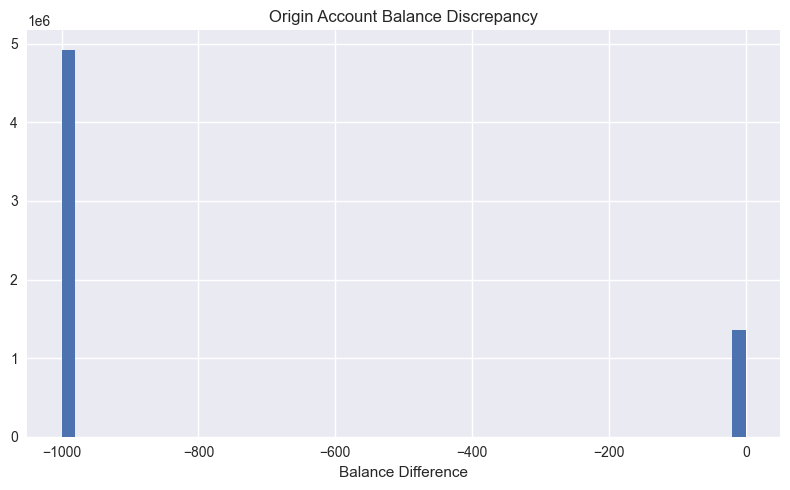

Large discrepancies may indicate suspicious manipulation.


In [12]:
# Expected balance after transaction
df['orig_balance_diff'] = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']

plt.figure(figsize=(8,5))
plt.hist(df['orig_balance_diff'].clip(-1000,1000), bins=50)
plt.title("Origin Account Balance Discrepancy")
plt.xlabel("Balance Difference")
plt.tight_layout()
plt.show()

print("Large discrepancies may indicate suspicious manipulation.")


## 4. Class Imbalance Study

In [13]:
fraud_count = df['isFraud'].sum()
total_count = len(df)

imbalance_ratio = total_count / fraud_count

print(f"Fraud cases: {fraud_count}")
print(f"Total transactions: {total_count}")
print(f"Imbalance ratio (Legit:Fraud) ≈ {imbalance_ratio:.0f}:1")


Fraud cases: 8213
Total transactions: 6362620
Imbalance ratio (Legit:Fraud) ≈ 775:1
